Processando a série histórica na nuvem do Earth Engine...
✅ Ano 2016 processado.
✅ Ano 2017 processado.
✅ Ano 2018 processado.
✅ Ano 2019 processado.
✅ Ano 2020 processado.
✅ Ano 2021 processado.
✅ Ano 2022 processado.
✅ Ano 2023 processado.
✅ Ano 2024 processado.
✅ Ano 2025 processado.

 Planilha 'ndvi_valores_finais.csv' exportada.


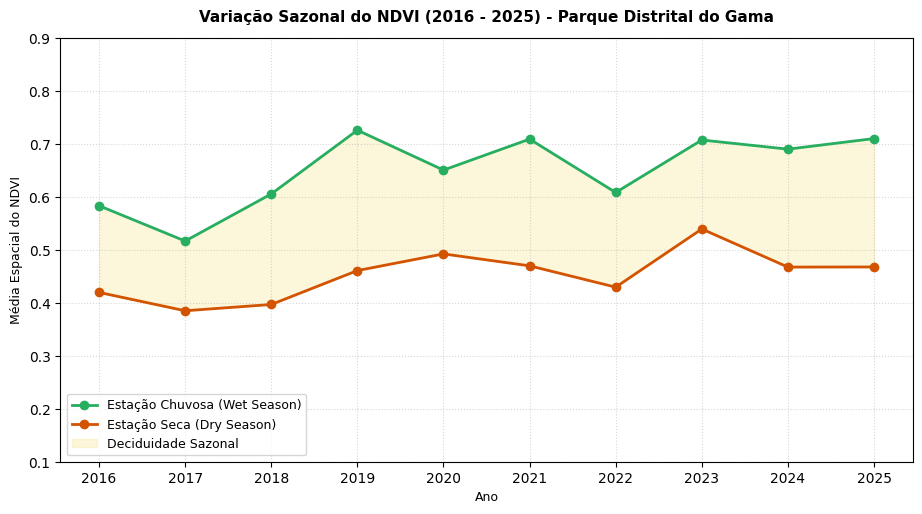

In [25]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


datas_seca = {
    2016: '2016-08-11', 2017: '2017-09-25',
    2018: '2018-09-05',
    2019: '2019-09-15', 2020: '2020-09-29', 2021: '2021-08-25', 
    2022: '2022-08-30', 2023: '2023-08-05', 2024: '2024-09-03', 
    2025: '2025-09-15'
}

datas_chuva = {
    2016: '2016-04-13',
    2017: '2017-11-14', 
    2018: '2018-11-29',
    2019: '2019-12-29', 2020: '2020-11-08', 2021: '2021-01-27',
    2022: '2022-11-13', 2023: '2023-12-13', 2024: '2024-12-07',
    2025: '2025-03-07'
}

data_records = []
years_all = sorted(list(set(list(datas_seca.keys()) + list(datas_chuva.keys()))))

print("Processando a série histórica na nuvem do Earth Engine...")

for year in years_all:
    date_dry = datas_seca.get(year)
    date_rain = datas_chuva.get(year)
    
    mean_dry = None
    mean_rain = None
    

    # SECA: Ajuste de coleção para 2015 e 2018 (L1C/Top of Atmosphere)
    if date_dry:
        colecao_seca = 'COPERNICUS/S2' if year in [2015, 2018] else 'COPERNICUS/S2_SR_HARMONIZED'
        # Evita problemas de fuso horário recuando 1 dia nas imagens críticas
        start_dry_filter = '2015-09-15' if year == 2015 else ('2018-09-04' if year == 2018 else date_dry)
        
        try:
            img_dry = (ee.ImageCollection(colecao_seca)
                       .filterBounds(roi)
                       .filterDate(start_dry_filter, ee.Date(date_dry).advance(2, 'day'))
                       .map(mask_s2_clouds)
                       .map(calculate_ndvi)
                       .first()
                       .clip(roi))
            stats_dry = img_dry.select('NDVI').reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=10).getInfo()
            mean_dry = stats_dry.get('NDVI')
        except Exception as e:
            print(f"⚠️ Alerta na Seca de {year}: Verificar a janela de dados no GEE.")


    # CHUVA: Ajuste de coleção para 2016 e 2018 (L1C)
    if date_rain:
        # 2016 e 2018 usam a coleção S2 padrão por serem imagens L1C
        colecao_chuva = 'COPERNICUS/S2' if year <= 2018 else 'COPERNICUS/S2_SR_HARMONIZED'
        
        # Compensação crucial de fuso horário UTC abrindo a janela 1 dia antes
        if year == 2016:
            start_rain_filter = '2016-04-12' # <--- Abre a janela dia 12 para achar a cena do dia 13
        elif year == 2018:
            start_rain_filter = '2018-11-28'
        else:
            start_rain_filter = date_rain
        
        try:
            img_rain = (ee.ImageCollection(colecao_chuva)
                        .filterBounds(roi)
                        .filterDate(start_rain_filter, ee.Date(date_rain).advance(2, 'day'))
                        .map(mask_s2_clouds)
                        .map(calculate_ndvi)
                        .first()
                        .clip(roi))
            stats_rain = img_rain.select('NDVI').reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=10).getInfo()
            mean_rain = stats_rain.get('NDVI')
        except Exception as e:
            print(f"⚠️ Alerta na Chuva de {year}: Verifique a janela de dados no GEE.")
            
    # Armazenando os registros válidos
    if mean_dry is not None or mean_rain is not None:
        data_records.append({
            'Year': year,
            'NDVI_Rainy': mean_rain if mean_rain is not None else np.nan,
            'NDVI_Dry': mean_dry if mean_dry is not None else np.nan,
            'NDVI_Drop': (mean_rain - mean_dry) if (mean_rain is not None and mean_dry is not None) else np.nan,
            'Date_Rainy': date_rain if date_rain else 'Sem Informação',
            'Date_Dry': date_dry if date_dry else 'Sem Informação'
        })
        print(f"✅ Ano {year} processado.")


#SALVAR PLANILHA DE DADOS
df_tcc = pd.DataFrame(data_records)
df_tcc.to_csv("ndvi_valores_finais_tcc.csv", index=False)
print("\n Planilha 'ndvi_valores_finais.csv' exportada.")


#PLOTAR GRÁFICO DE LINHAS DA SAZONALIDADE
plt.figure(figsize=(11, 5.5))

df_rain_plot = df_tcc.dropna(subset=['NDVI_Rainy'])
df_dry_plot = df_tcc.dropna(subset=['NDVI_Dry'])

# Plot das linhas de tendência histórica
plt.plot(df_rain_plot['Year'], df_rain_plot['NDVI_Rainy'], marker='o', color='#27ae60', linewidth=2, label='Estação Chuvosa (Wet Season)')
plt.plot(df_dry_plot['Year'], df_dry_plot['NDVI_Dry'], marker='o', color='#d35400', linewidth=2, label='Estação Seca (Dry Season)')

# Preenchimento do intervalo para destacar a perda de deciduidade
df_gap = df_tcc.dropna(subset=['NDVI_Rainy', 'NDVI_Dry'])
plt.fill_between(df_gap['Year'], df_gap['NDVI_Rainy'], df_gap['NDVI_Dry'], color='#f1c40f', alpha=0.15, label='Deciduidade Sazonal')

# Configurações do layout científico
plt.title('Variação Sazonal do NDVI (2016 - 2025) - Parque Distrital do Gama', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Ano', fontsize=9)
plt.ylabel('Média Espacial do NDVI', fontsize=9)
plt.xticks(df_tcc['Year'])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', fontsize=9)
plt.ylim(0.1, 0.9)

# Salvar figura para o Word/Relatório
plt.savefig("grafico_sazonalidade_ndvi_final.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_32976\3456776308.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_custom = plt.cm.get_cmap('RdYlGn').copy()


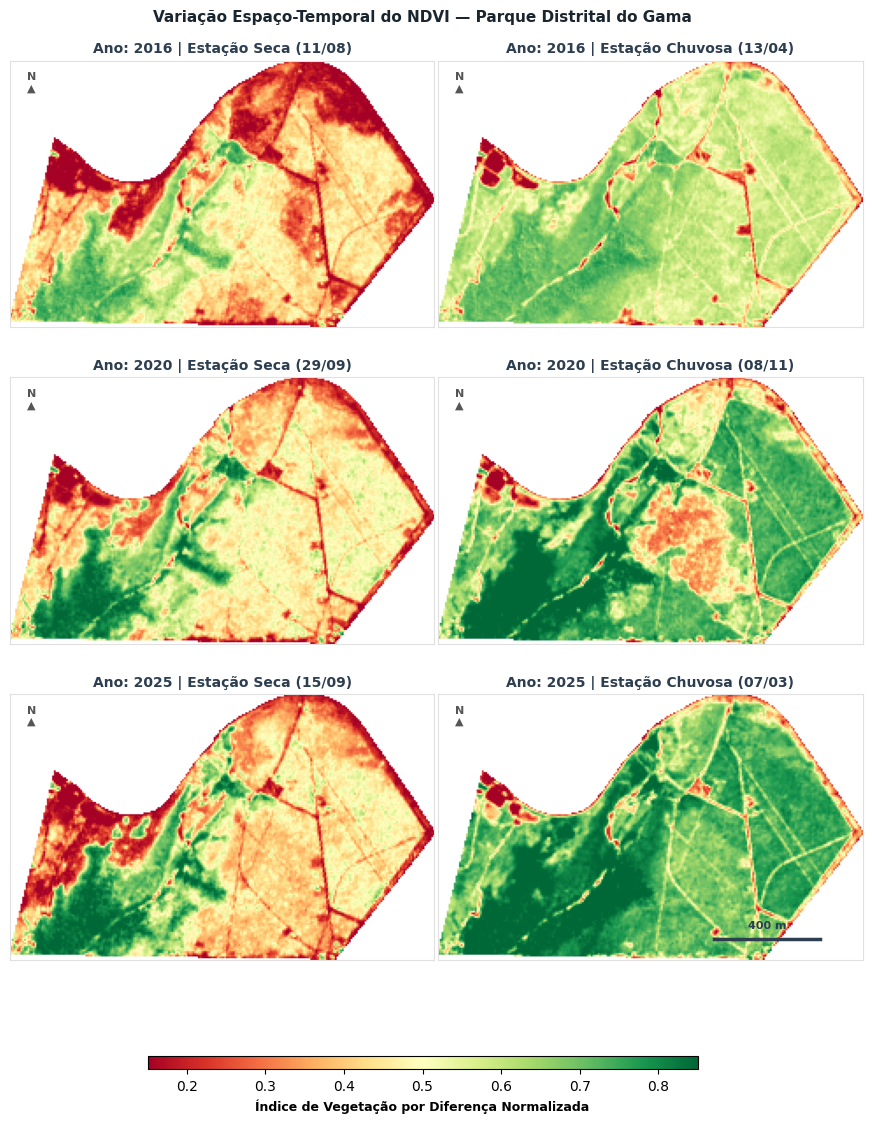

In [ ]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

anos_selecionados = [2016, 2020, 2025]


def processar_ndvi_s2(img, is_l1c=False):
    """Calcula o NDVI e aplica máscara de nuvens simplificada p teste"""
    # Máscara de nuvens usando a banda de QA60
    qa = img.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    img_masked = img.updateMask(mask)
    
    # Identifica as bandas corretas
    nir = img_masked.select('B8')
    red = img_masked.select('B4')
    
    # Calcula o NDVI
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    return ndvi

# LAYOUT DA PRANCHA
fig, axes = plt.subplots(len(anos_selecionados), 2, figsize=(9, 3.0 * len(anos_selecionados)), facecolor='#ffffff')
plt.subplots_adjust(wspace=0.01, hspace=0.05, bottom=0.12, top=0.94)

cmap_custom = plt.cm.get_cmap('RdYlGn').copy()
cmap_custom.set_bad(color='#ffffff', alpha=1.0)


datas_fixas_seca = {2016: '2016-08-11', 2020: '2020-09-29', 2025: '2025-09-15'}
datas_fixas_chuva = {2016: '2016-04-13', 2020: '2020-11-08', 2025: '2025-03-07'}


for idx, ano in enumerate(anos_selecionados):
    d_seca = datas_fixas_seca.get(ano)
    d_chuva = datas_fixas_chuva.get(ano)
    
    ax_dry = axes[idx, 0]
    ax_rain = axes[idx, 1]
    

    # ESTAÇÃO SECA (2016, 2020, 2025)
    if d_seca:
        try:
            img_dry = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                       .filterBounds(roi)
                       .filterDate(d_seca, ee.Date(d_seca).advance(5, 'day'))
                       .first())
            
            ndvi_dry = processar_ndvi_s2(img_dry).clip(roi)
            arr_dry = geemap.ee_to_numpy(ndvi_dry, region=roi, scale=10)
            arr_dry = np.where(arr_dry == 0, np.nan, arr_dry)
            
           # Adiciona uma folga de 5 pixels nas bordas para não comer o polígono
                ymin_d = max(0, ymin_d - 5)
                ymax_d = min(arr_dry.shape[0], ymax_d + 5)
                xmin_d = max(0, xmin_d - 5)
                xmax_d = min(arr_dry.shape[1], xmax_d + 5)
                
                arr_dry_cropped = arr_dry[ymin_d:ymax_d, xmin_d:xmax_d]
                
                im_dry = ax_dry.imshow(arr_dry_cropped, cmap=cmap_custom, vmin=0.15, vmax=0.85)
                ax_dry.set_title(f"Ano: {ano} | Estação Seca ({d_seca[8:10]}/{d_seca[5:7]})", fontsize=10, fontweight='bold', color='#2c3e50')
            else:
                ax_dry.text(0.5, 0.5, 'Sem pixels válidos', ha='center', va='center', color='#95a5a6')
        except Exception as e:
            ax_dry.text(0.5, 0.5, f'Erro na Seca de {ano}', ha='center', va='center', color='#e74c3c', fontsize=9)
            
  
    if d_chuva:
        col_chuva = 'COPERNICUS/S2' if ano == 2016 else 'COPERNICUS/S2_SR_HARMONIZED'
        f_rain = '2016-04-12' if ano == 2016 else d_chuva
        
        try:
            img_rain = (ee.ImageCollection(col_chuva)
                        .filterBounds(roi)
                        .filterDate(f_rain, ee.Date(f_rain).advance(5, 'day'))
                        .first())
            
            ndvi_rain = processar_ndvi_s2(img_rain).clip(roi)
            arr_rain = geemap.ee_to_numpy(ndvi_rain, region=roi, scale=10)
            arr_rain = np.where(arr_rain == 0, np.nan, arr_rain)
            
           # Adiciona uma folga de 5 pixels nas bordas para não comer o polígono
                ymin_r = max(0, ymin_r - 5)
                ymax_r = min(arr_rain.shape[0], ymax_r + 5)
                xmin_r = max(0, xmin_r - 5)
                xmax_r = min(arr_rain.shape[1], xmax_r + 5)
                
                arr_rain_cropped = arr_rain[ymin_r:ymax_r, xmin_r:xmax_r]
                
                im_rain = ax_rain.imshow(arr_rain_cropped, cmap=cmap_custom, vmin=0.15, vmax=0.85)
                ax_rain.set_title(f"Ano: {ano} | Estação Chuvosa ({d_chuva[8:10]}/{d_chuva[5:7]})", fontsize=10, fontweight='bold', color='#2c3e50')
            else:
                ax_rain.text(0.5, 0.5, 'Sem pixels válidos', ha='center', va='center', color='#95a5a6')
        except Exception as e:
            ax_rain.text(0.5, 0.5, f'Erro na Chuva de {ano}', ha='center', va='center', color='#e74c3c', fontsize=9)


    # AJUSTES DE BORDA E ORIENTAÇÃO DO QUADRANTE
    ax_dry.set_xticks([]); ax_dry.set_yticks([])
    ax_rain.set_xticks([]); ax_rain.set_yticks([])
    for spine in ax_dry.spines.values(): spine.set_color('#e0e0e0')
    for spine in ax_rain.spines.values(): spine.set_color('#e0e0e0')
    ax_dry.text(0.05, 0.92, 'N\n▲', ha='center', va='center', fontsize=8, fontweight='bold', color='#555555', transform=ax_dry.transAxes)
    ax_rain.text(0.05, 0.92, 'N\n▲', ha='center', va='center', fontsize=8, fontweight='bold', color='#555555', transform=ax_rain.transAxes)


axes[-1, 1].plot([0.65, 0.9], [0.08, 0.08], color='#2c3e50', linewidth=2.5, transform=axes[-1, 1].transAxes)
axes[-1, 1].text(0.775, 0.12, '400 m', ha='center', fontsize=8, fontweight='bold', color='#2c3e50', transform=axes[-1, 1].transAxes)


plt.suptitle('Variação Espaço-Temporal do NDVI — Parque Distrital do Gama', fontsize=11, fontweight='bold', color='#1a252f', y=0.97)
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.012])
cbar = fig.colorbar(im_dry, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Índice de Vegetação por Diferença Normalizada', fontsize=9, fontweight='bold', labelpad=4)

plt.savefig("prancha_ndvi_3anos_final.png", dpi=300, bbox_inches='tight')
plt.show()